### 1. Exploratory Data Analysis (EDA):

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

In [2]:
df = pd.read_excel("glass.xlsx", sheet_name="glass")

In [3]:
df.shape

(214, 10)

In [4]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [6]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [7]:
#checkig missing values
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [8]:
#checking duplicates
df.duplicated().sum()

1

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

0

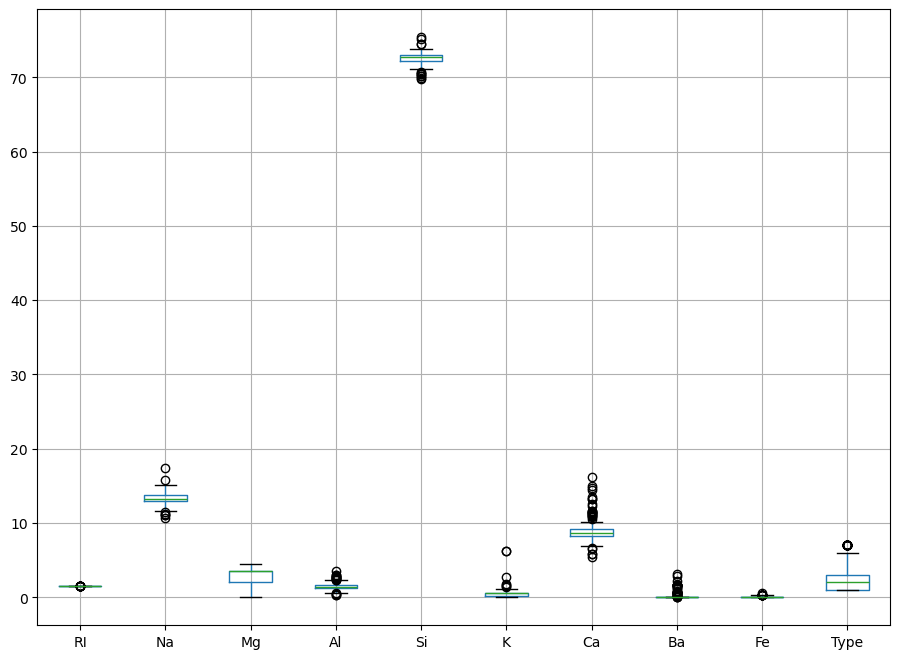

In [11]:
#checking outliers by using boxplot
plt.figure(figsize=(11,8))
df.boxplot()
plt.show()

In [12]:
#outlier capping 
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    high_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else high_extreme if x>high_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

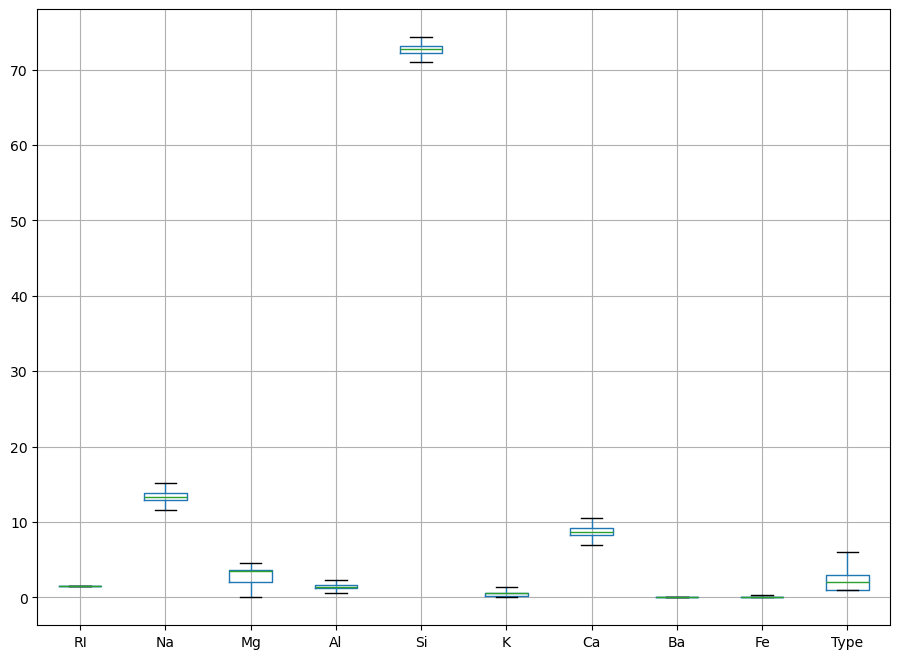

In [13]:
#checking outliers by using boxplot after outlier capping
plt.figure(figsize=(11,8))
df.boxplot()
plt.show()

### 2: Data Visualization:

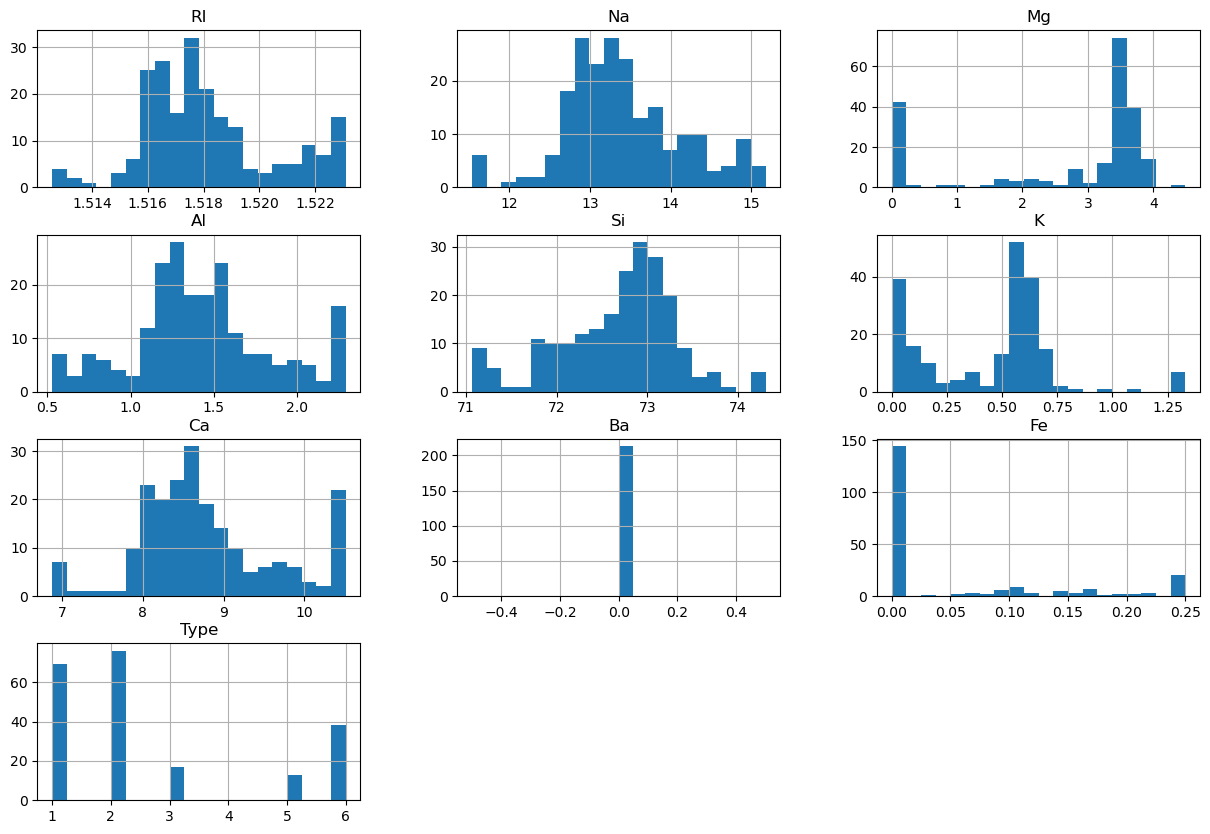

In [14]:
df.hist(figsize=(15,10), bins=20)
plt.show()

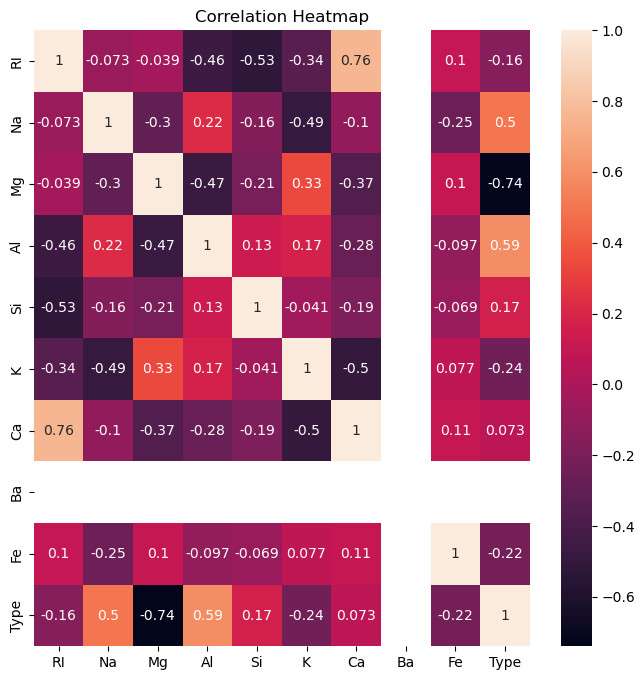

In [15]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

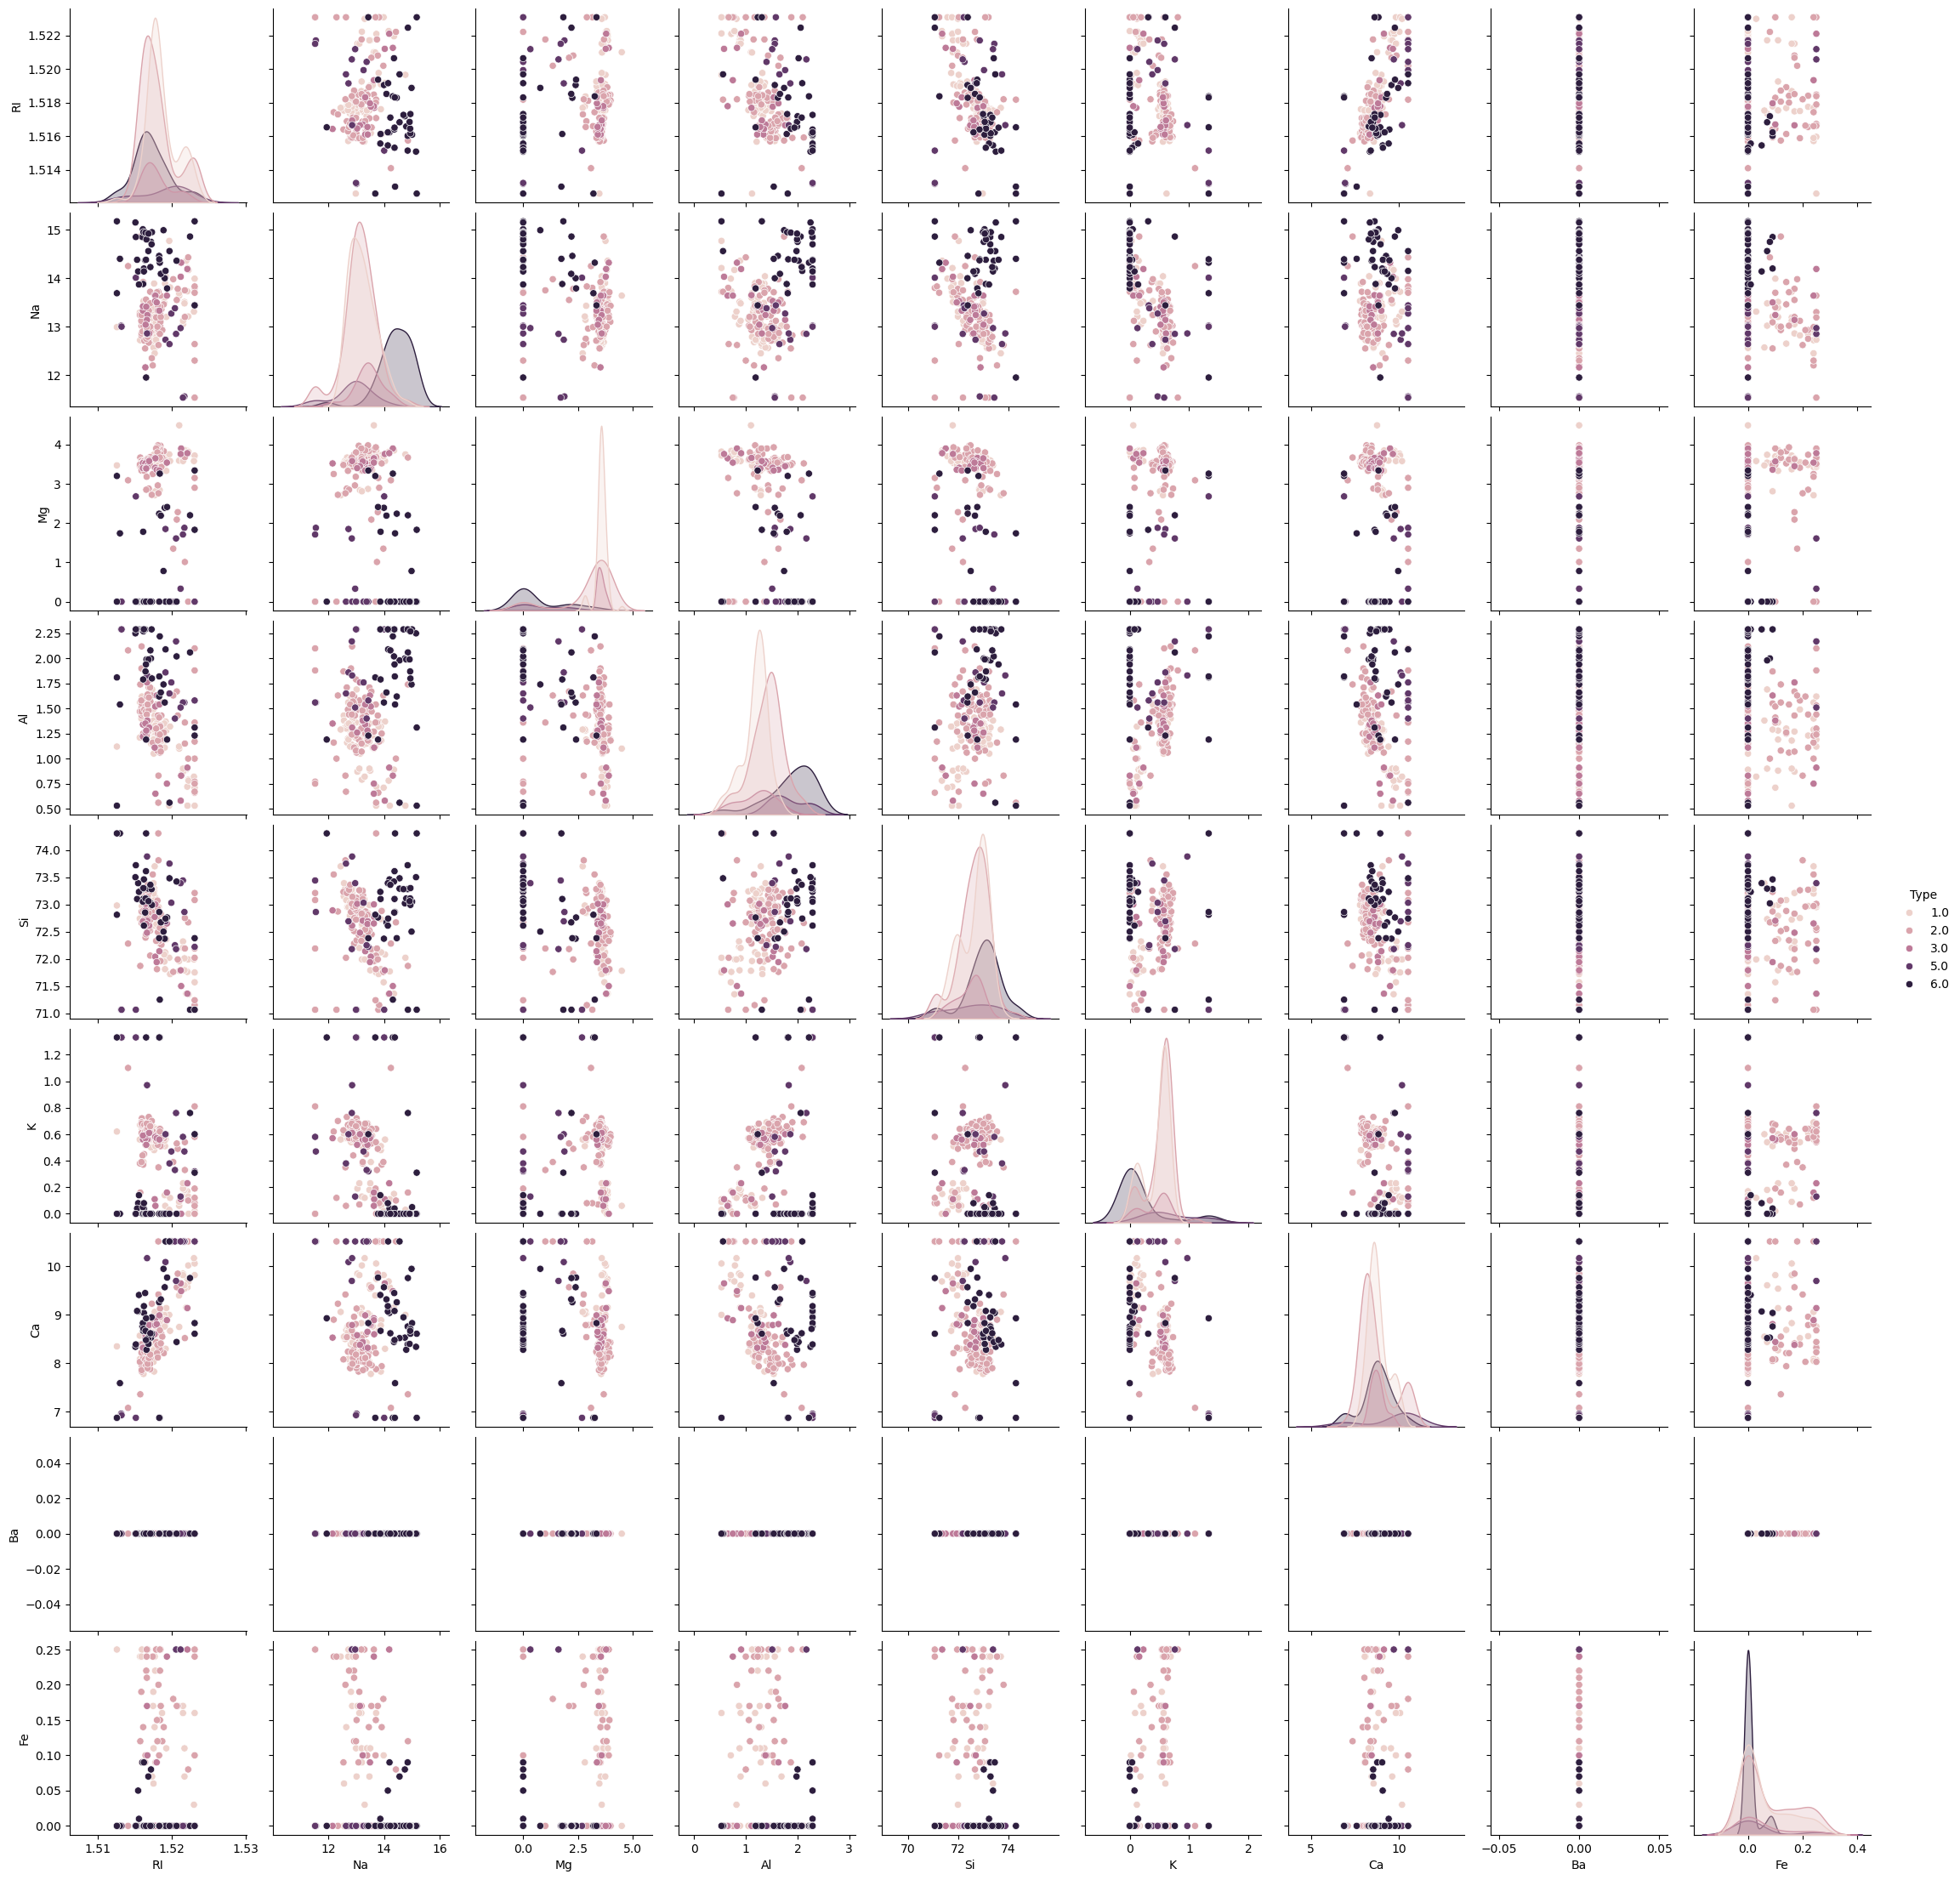

In [16]:
# pair plot
sns.pairplot(df, hue='Type')
plt.show()

### 3: Data Preprocessing

In [17]:
df.isnull().sum() # no missing values.so imputation is not required

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [18]:
features=df.drop('Type',axis=1)
target=df[['Type']]

In [19]:
# No categorical input features are present in this dataset.
# Therefore encoding is not required.

In [20]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

features_scaled = scaler.fit_transform(features)

In [21]:
# Convert back to DataFrame
features_scaled = pd.DataFrame(features_scaled, columns=features.columns)
features_scaled.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.216093,0.322680,1.257238,-0.773927,-1.361078,-1.253536,-0.044419,0.0,-0.621102
1,-0.227207,0.660556,0.639311,-0.154741,0.086641,0.124799,-1.115733,0.0,-0.621102
2,-0.834242,0.174014,0.604596,0.273927,0.482859,-0.170559,-1.173956,0.0,-0.621102
3,-0.205982,-0.258467,0.701798,-0.321445,-0.096228,0.420156,-0.661589,0.0,-0.621102
4,-0.307862,-0.177377,0.653197,-0.440519,0.620012,0.354521,-0.836260,0.0,-0.621102


In [22]:
# Checking Class Imbalance
print("Class Distribution Before SMOTE")
print(target.value_counts())

Class Distribution Before SMOTE
Type
2.0     76
1.0     69
6.0     38
3.0     17
5.0     13
Name: count, dtype: int64


In [23]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)

features_resampled, target_resampled = smote.fit_resample(features_scaled, target)
# Check balanced classes
print(target_resampled.value_counts())

Type
1.0     76
2.0     76
3.0     76
5.0     76
6.0     76
Name: count, dtype: int64


### 4: Random Forest Model Implementation

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [25]:
x_train,x_test,y_train,y_test=train_test_split(features_resampled,target_resampled,train_size=0.8,random_state=50)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(304, 9)
(76, 9)
(304, 1)
(76, 1)


In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
rand=RandomForestClassifier(n_estimators=100,max_features='sqrt',random_state=50) #100 sets of decision tree ,we have only decision tree on random forest
rand.fit(x_train,y_train)

RandomForestClassifier(random_state=50)

In [28]:
y_pred=rand.predict(x_test)
accuracy_score(y_test,y_pred)

0.8157894736842105

In [29]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.71      0.83      0.77        18
         2.0       0.71      0.60      0.65        20
         3.0       1.00      0.93      0.96        14
         5.0       0.83      1.00      0.91        10
         6.0       0.92      0.86      0.89        14

    accuracy                           0.82        76
   macro avg       0.84      0.84      0.84        76
weighted avg       0.82      0.82      0.81        76



In [30]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

[[15  3  0  0  0]
 [ 5 12  0  2  1]
 [ 1  0 13  0  0]
 [ 0  0  0 10  0]
 [ 0  2  0  0 12]]


<Axes: >

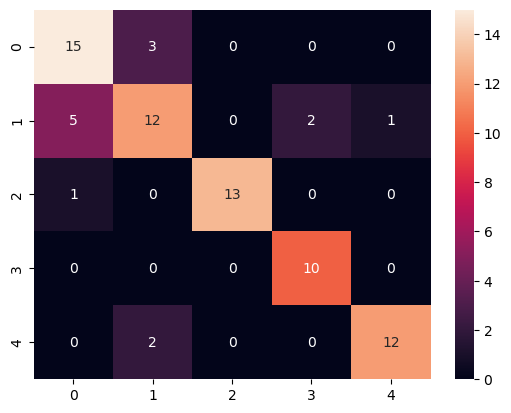

In [31]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [32]:
## grid search ,it is used to search the hyper parameter values and give the best value
from sklearn.model_selection import GridSearchCV

In [33]:
## grid search
params={'n_estimators':[50,100,150,200]}
grid_sea=GridSearchCV(estimator=rand,param_grid=params,cv=5)
grid_sea.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=50),
             param_grid={'n_estimators': [50, 100, 150, 200]})

In [34]:
grid_sea.best_params_,grid_sea.best_score_

({'n_estimators': 50}, 0.8653005464480874)

In [35]:
rand=RandomForestClassifier(n_estimators=50,max_features='sqrt',random_state=50)
rand.fit(x_train,y_train)

RandomForestClassifier(n_estimators=50, random_state=50)

In [36]:
y_pred1=rand.predict(x_test)
accuracy_score(y_test,y_pred1)

0.8289473684210527

In [37]:
# Classification Report
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

         1.0       0.75      0.83      0.79        18
         2.0       0.72      0.65      0.68        20
         3.0       0.93      0.93      0.93        14
         5.0       0.83      1.00      0.91        10
         6.0       1.00      0.86      0.92        14

    accuracy                           0.83        76
   macro avg       0.85      0.85      0.85        76
weighted avg       0.83      0.83      0.83        76



### 5: Bagging and Boosting Methods

In [ ]:
# bagging mathod

In [38]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
baggcl=BaggingClassifier(estimator=LogisticRegression(),n_estimators=100,bootstrap=True,bootstrap_features=True) #n_estimators means how many sets of model 
baggcl.fit(x_train,y_train)

BaggingClassifier(bootstrap_features=True, estimator=LogisticRegression(),
                  n_estimators=100)

In [39]:
y_pred2=baggcl.predict(x_test)
accuracy_score(y_test,y_pred2)

0.75

In [40]:
# Classification Report
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

         1.0       0.65      0.72      0.68        18
         2.0       0.85      0.55      0.67        20
         3.0       0.69      0.79      0.73        14
         5.0       0.71      1.00      0.83        10
         6.0       0.92      0.86      0.89        14

    accuracy                           0.75        76
   macro avg       0.76      0.78      0.76        76
weighted avg       0.77      0.75      0.75        76



In [ ]:
# boosting methods-AdaBoost

In [41]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
ada_boost=AdaBoostClassifier(estimator=LogisticRegression(),n_estimators=100)
ada_boost.fit(x_train,y_train)
y_pred_ada= ada_boost.predict(x_test)
accuracy_score(y_test,y_pred_ada)

0.7368421052631579

In [42]:
# Classification Report
print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

         1.0       0.55      0.89      0.68        18
         2.0       0.72      0.65      0.68        20
         3.0       0.80      0.29      0.42        14
         5.0       1.00      1.00      1.00        10
         6.0       0.93      0.93      0.93        14

    accuracy                           0.74        76
   macro avg       0.80      0.75      0.74        76
weighted avg       0.77      0.74      0.72        76



In [43]:
params= {'n_estimators':[50,100,150,200]}
grid_search= GridSearchCV(estimator=ada_boost,param_grid=params, cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_, grid_search.best_score_

({'n_estimators': 50}, 0.6053005464480874)

In [44]:
ada_boost=AdaBoostClassifier(estimator=LogisticRegression(),n_estimators=50)
ada_boost.fit(x_train,y_train)
y_pred_ada1= ada_boost.predict(x_test)
accuracy_score(y_test,y_pred_ada1)

0.75

In [45]:
# Classification Report
print(classification_report(y_test, y_pred_ada1))

              precision    recall  f1-score   support

         1.0       0.60      0.83      0.70        18
         2.0       0.67      0.70      0.68        20
         3.0       0.80      0.29      0.42        14
         5.0       1.00      1.00      1.00        10
         6.0       0.93      1.00      0.97        14

    accuracy                           0.75        76
   macro avg       0.80      0.76      0.75        76
weighted avg       0.77      0.75      0.73        76



In [ ]:
# boosting methods-GradientBoost

In [46]:
from sklearn.ensemble import GradientBoostingClassifier
grad_boost= GradientBoostingClassifier(learning_rate=0.5,n_estimators=100)
grad_boost.fit(x_train,y_train)
y_pred_gra= grad_boost.predict(x_test)
accuracy_score(y_test,y_pred_gra)

0.8421052631578947

In [47]:
# Classification Report
print(classification_report(y_test, y_pred_gra))

              precision    recall  f1-score   support

         1.0       0.79      0.83      0.81        18
         2.0       0.85      0.85      0.85        20
         3.0       0.85      0.79      0.81        14
         5.0       0.91      1.00      0.95        10
         6.0       0.85      0.79      0.81        14

    accuracy                           0.84        76
   macro avg       0.85      0.85      0.85        76
weighted avg       0.84      0.84      0.84        76



In [48]:
params= {'n_estimators':[50,100],'learning_rate':[0.5,0.8]}
grid_search= GridSearchCV(estimator=grad_boost,param_grid=params, cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_, grid_search.best_score_

({'learning_rate': 0.8, 'n_estimators': 50}, 0.8455191256830602)

In [49]:
grad_boost= GradientBoostingClassifier(learning_rate=0.8,n_estimators=50)
grad_boost.fit(x_train,y_train)
y_pred_gra1= grad_boost.predict(x_test)
accuracy_score(y_test,y_pred_gra1)

0.8026315789473685

In [50]:
# Classification Report
print(classification_report(y_test, y_pred_gra1))

              precision    recall  f1-score   support

         1.0       0.74      0.78      0.76        18
         2.0       0.79      0.75      0.77        20
         3.0       0.85      0.79      0.81        14
         5.0       0.91      1.00      0.95        10
         6.0       0.79      0.79      0.79        14

    accuracy                           0.80        76
   macro avg       0.81      0.82      0.82        76
weighted avg       0.80      0.80      0.80        76



### Additional Notes:

In [ ]:
2. Handling Imbalanced Data
Imbalanced data occurs when some classes have many more samples than others.
It can make the model biased toward majority classes and reduce minority class prediction accuracy.
Techniques like Oversampling, Undersampling, and SMOTE are used to balance the data.
SMOTE creates synthetic samples for minority classes instead of duplicating data.
Balanced data improves model performance, especially recall and F1-score for minority classes.